# Solar Power Forecasting Using NSRDB Hourly Data

**Goal:** Forecast next-day solar output proxies using NSRDB weather/irradiance features.

This starter notebook assumes you downloaded **hourly CSV** from the **NREL NSRDB Viewer**:
https://nsrdb.nrel.gov/nsrdb-viewer

### What you will produce
- A **baseline** model (persistence)
- A **linear regression** model
- A **random forest** model
- Proper **time-based split** + **MAE/RMSE**
- Plots: **actual vs predicted**, **error distribution**, **feature importance**

### What to forecast
If you do not have real PV power output data, you can forecast **GHI** (Global Horizontal Irradiance) as a strong proxy.
Later you can map irradiance → PV power using a simple efficiency model.


# Solar Power Forecasting Using NSRDB Hourly Data

## Background and Motivation

Accurate forecasting of solar energy production is a critical component of modern power-system operations, renewable energy integration, and energy-market planning. Solar photovoltaic (PV) output exhibits strong variability across multiple time scales due to diurnal cycles, seasonal changes, cloud cover, and atmospheric conditions. As solar penetration increases, grid operators and energy planners rely on short-term forecasts (hourly to day-ahead) to support dispatch decisions, reserve allocation, and grid stability.

Because direct PV power measurements are not always publicly available, solar irradiance variables—particularly **Global Horizontal Irradiance (GHI)**—are widely used as physically meaningful proxies for solar power potential. Data-driven forecasting models trained on irradiance and meteorological variables have therefore become standard tools in applied renewable-energy analytics.

This project develops a **data-science workflow for hourly solar forecasting** using publicly available, high-resolution meteorological and radiative data from the **National Solar Radiation Database (NSRDB)**.

---

## Global Horizontal Irradiance (GHI)

Global Horizontal Irradiance (GHI) represents the total shortwave solar radiation received by a horizontal surface at the Earth’s surface. It is composed of two physically distinct components:

- **Direct Normal Irradiance** projected onto the horizontal plane  
- **Diffuse Horizontal Irradiance** resulting from atmospheric scattering

**GHI** represents the total amount of solar radiation received per unit area on a horizontal surface at the Earth’s surface, typically expressed in watts per square meter (W/m²). It consists of two primary components: **Direct Normal Irradiance (DNI)** and **Diffuse Horizontal Irradiance (DHI)**. DNI refers to solar radiation that travels directly from the sun to the surface without scattering, while DHI accounts for radiation that reaches the surface after being scattered within the atmosphere. Atmospheric constituents such as water vapor, aerosols, and clouds absorb and reflect incoming solar radiation, redistributing it as diffuse energy. The figure below shows the difference between the DNI and DHI.

In physical terms, GHI can be expressed as:

$$
GHI = DNI \times \cos(\theta_z) + DHI
$$

where:

- $DNI$ is the direct normal irradiance  
- $DHI$ is the diffuse horizontal irradiance  
- $\theta_z$ is the solar zenith angle  

GHI is widely used in solar-energy studies because it captures both clear-sky and cloudy-sky conditions and exhibits a strong correlation with photovoltaic power output, particularly for fixed-tilt PV systems and regional-scale assessments.

![DHI and DNI](figures/DHI_DNI.png)

---
## The National Solar Radiation Database (NSRDB)

The **National Solar Radiation Database (NSRDB)** is a publicly available dataset developed and maintained by the **U.S. National Renewable Energy Laboratory (NREL)**. It provides gridded estimates of solar radiation and meteorological variables derived from satellite observations, numerical weather prediction models, and radiative transfer calculations.

The NSRDB data used in this project have the following key characteristics:

- **Hourly temporal resolution**
- **High spatial resolution (approximately 2 km for Asia–Pacific regions)**
- Consistent quality control across years
- Coverage of both radiative and meteorological variables relevant to solar energy applications

NSRDB data are widely used in solar resource assessment, PV system design, power forecasting research, and grid-integration studies.

---

## Selected Variables and Physical Rationale

The following variables are used as predictors in this study:

### Radiative variables
- **Global Horizontal Irradiance (GHI)**  
  Used as the forecast target and a proxy for solar PV output  
- **Direct Normal Irradiance (DNI)**  
  Indicates the strength of direct solar radiation under clear-sky conditions  
- **Diffuse Horizontal Irradiance (DHI)**  
  Captures cloud and aerosol scattering effects  
- **Clear-sky GHI**  
  Represents the theoretical irradiance under cloud-free conditions and enables separation of cloud-driven variability

### Meteorological variables
- **Air temperature**  
  Influences atmospheric density and PV efficiency  
- **Relative humidity**  
  Serves as a proxy for atmospheric moisture and cloud formation  
- **Wind speed**  
  Related to boundary-layer mixing and cloud evolution processes

### Time and persistence features
- **Hour of day, day of year, and month**  
  Capture deterministic solar geometry and seasonal cycles  
- **Lagged GHI (t−1 and t−24 hours)**  
  Represent short-term persistence and diurnal repeatability  
- **Rolling averages of GHI**  
  Smooth high-frequency variability and encode recent atmospheric states

Together, these features encode both **physical drivers** and **statistical persistence**, which are essential for effective short-term solar forecasting.

---

## Project Scope

The scope of this project is to:

- Develop a reproducible data-science pipeline for **hourly solar irradiance forecasting**
- Compare a **persistence baseline** with machine-learning models
- Apply **time-aware train/test splitting** appropriate for time-series data
- Quantify forecast performance using **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**
- Identify dominant predictors using feature-importance analysis

The primary focus is on **hour-ahead to day-ahead forecasting**, which is directly relevant to operational energy planning and grid integration.

---

## Limitations

Several limitations of this study should be noted:

1. **Irradiance proxy**  
   The models forecast GHI rather than measured PV power. Actual PV output additionally depends on panel tilt, orientation, system efficiency, and losses.

2. **Single-location analysis**  
   Results are location-specific and may not generalize without retraining for other regions.

3. **Lack of explicit cloud-motion information**  
   Satellite cloud imagery and motion vectors, which can improve very short-term forecasts, are not included.

4. **Statistical modeling approach**  
   The models do not explicitly resolve physical cloud dynamics and instead rely on historical patterns and correlations.

Despite these limitations, the workflow reflects **industry-standard practice** for data-driven solar forecasting and provides a solid foundation for more advanced modeling approaches.

---

## References

- National Renewable Energy Laboratory (NREL). **National Solar Radiation Database (NSRDB)**  
  https://nsrdb.nrel.gov/

- Perez, R., et al. (2013). *Validation of the National Solar Radiation Database (NSRDB).*  
  Solar Energy, 93, 121–132.

- Lorenz, E., et al. (2014). *Regional photovoltaic power prediction for improved grid integration.*  
  IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing.

- Yang, D., et al. (2015). *Solar irradiance forecasting using time-series and machine learning methods.*  
  Renewable and Sustainable Energy Reviews, 44, 676–686.

- SolarAnywhere. *Solar Irradiance Data Field Definitions*.  
  Clean Power Research.  
  https://www.solaranywhere.com/support/data-fields/definitions/


## Setup



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.dpi'] = 130


In [2]:
# Define the paths to the data
DATA_PATHS = [
    'data/nsrdb_2019.csv',
    'data/nsrdb_2020.csv'
]

# Load and concatenate multiple yearly NSRDB files

dfs = []

for path in DATA_PATHS:
    assert os.path.exists(path), f"File not found: {path}"
    df_year = pd.read_csv(path)
    dfs.append(df_year)

df_raw = pd.concat(dfs, ignore_index=False)

print("Loaded rows:", len(df_raw))
df_raw.head()

Loaded rows: 17524


,Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
0,NSRDB,4954849,-,b'Metropolitan Manila',b'Philippines',14.6,120.97,0,10,8,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,NaN,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,NaN,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,NaN,unknown
1,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,GHI,DNI,DHI,Relative Humidity,Wind Direction,Wind Speed,Surface Albedo,Cloud Type,Clearsky DNI,Clearsky DHI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,0,0,26,272,272,399,132,93.57000000000001,70,2.4000000000000004,0.1,1,399,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,1,0,26.5,472,248,47,223,91.99,69,2.7,0.1,2,576,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,2,0,27.1,633,313,41,286,88.52,69,3.1,0.1,3,666,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Load raw CSV (per year already concatenated)
df_raw = df_raw.reset_index(drop=True)

# Step 1: Extract the true header row (row index 1)
new_columns = df_raw.iloc[1].values
df_clean = df_raw.iloc[2:].copy()

# Step 2: Assign proper column names
df_clean.columns = new_columns

# Step 3: Reset index
df_clean = df_clean.reset_index(drop=True)

# Step 4: Convert numeric columns safely 

for col in df_clean.columns:
    try:
        df_clean[col] = pd.to_numeric(df_clean[col])
    except (ValueError, TypeError):
        # Leave non-numeric columns (e.g. Cloud Type) untouched
        pass

df_clean.head()


,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,GHI,DNI,DHI,Relative Humidity,Wind Direction,Wind Speed,Surface Albedo,Cloud Type,Clearsky DNI,Clearsky DHI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2019,1,1,0,0,26,272,272,399,132,93.57000000000001,70,2.4000000000000004,0.1,1,399,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,1,1,1,0,26.5,472,248,47,223,91.99,69,2.7,0.1,2,576,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,2,0,27.1,633,313,41,286,88.52,69,3.1,0.1,3,666,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,3,0,27.700000000000003,744,442,94,371,84.39,71,3.4000000000000004,0.1,3,743,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,4,0,28.200000000000003,779,540,174,402,81.14,74,3.6,0.1,3,753,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_clean.dtypes

Year                  object
Month                 object
Day                   object
Hour                  object
Minute                object
Temperature           object
Clearsky GHI          object
GHI                   object
DNI                   object
DHI                   object
Relative Humidity     object
Wind Direction        object
Wind Speed            object
Surface Albedo        object
Cloud Type            object
Clearsky DNI          object
Clearsky DHI          object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                  float64
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN                   object
NaN           

In [5]:
# Select columns needed as provided above
df = df_clean[['Year','Month','Day','Hour','Minute','Temperature','Clearsky GHI','GHI',
               'DNI','DHI','Relative Humidity','Wind Direction','Wind Speed']]
df.head()

,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,GHI,DNI,DHI,Relative Humidity,Wind Direction,Wind Speed
0,2019,1,1,0,0,26,272,272,399,132,93.57000000000001,70,2.4000000000000004
1,2019,1,1,1,0,26.5,472,248,47,223,91.99,69,2.7
2,2019,1,1,2,0,27.1,633,313,41,286,88.52,69,3.1
3,2019,1,1,3,0,27.700000000000003,744,442,94,371,84.39,71,3.4000000000000004
4,2019,1,1,4,0,28.200000000000003,779,540,174,402,81.14,74,3.6


In [6]:
# Inspect missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17522 entries, 0 to 17521
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               17522 non-null  object
 1   Month              17522 non-null  object
 2   Day                17522 non-null  object
 3   Hour               17522 non-null  object
 4   Minute             17522 non-null  object
 5   Temperature        17522 non-null  object
 6   Clearsky GHI       17522 non-null  object
 7   GHI                17522 non-null  object
 8   DNI                17522 non-null  object
 9   DHI                17522 non-null  object
 10  Relative Humidity  17522 non-null  object
 11  Wind Direction     17522 non-null  object
 12  Wind Speed         17522 non-null  object
dtypes: object(13)
memory usage: 1.7+ MB


In [7]:
df.columns.to_list()

['Year',
 'Month',
 'Day',
 'Hour',
 'Minute',
 'Temperature',
 'Clearsky GHI',
 'GHI',
 'DNI',
 'DHI',
 'Relative Humidity',
 'Wind Direction',
 'Wind Speed']

## Parse datetime
NSRDB exports often include columns like `Year`, `Month`, `Day`, `Hour`, `Minute`.

This cell tries to build a `datetime` index.


In [8]:
df = df.copy()

# Try to build a datetime column from common NSRDB fields
possible_parts = ['Year', 'Month', 'Day', 'Hour', 'Minute']
has_parts = all(col in df.columns for col in ['Year', 'Month', 'Day', 'Hour'])

if has_parts:
    if 'Minute' not in df.columns:
        df['Minute'] = 0
    df['dt'] = pd.to_datetime(
        dict(year=df['Year'], month=df['Month'], day=df['Day'], hour=df['Hour'], minute=df['Minute']),
        errors='coerce'
    )
elif 'datetime' in df.columns:
    df['dt'] = pd.to_datetime(df['datetime'], errors='coerce')
elif 'time' in df.columns:
    df['dt'] = pd.to_datetime(df['time'], errors='coerce')
else:
    # If this fails, print columns and manually set parsing.
    raise ValueError(
        "Could not find datetime fields.\n"
        "Look at df.columns and add a custom parser in this cell."
    )

df = df.dropna(subset=['dt']).sort_values('dt').set_index('dt')
df.index.name = 'datetime'

df.head()

,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,GHI,DNI,DHI,Relative Humidity,Wind Direction,Wind Speed
datetime,,,,,,,,,,,,,
2019-01-01 00:00:00,2019,1,1,0,0,26,272,272,399,132,93.57000000000001,70,2.4000000000000004
2019-01-01 01:00:00,2019,1,1,1,0,26.5,472,248,47,223,91.99,69,2.7
2019-01-01 02:00:00,2019,1,1,2,0,27.1,633,313,41,286,88.52,69,3.1
2019-01-01 03:00:00,2019,1,1,3,0,27.700000000000003,744,442,94,371,84.39,71,3.4000000000000004
2019-01-01 04:00:00,2019,1,1,4,0,28.200000000000003,779,540,174,402,81.14,74,3.6


## Quick EDA 
To check missing values and the target distribution.


In [9]:
print('Rows:', len(df))
print('Date range:', df.index.min(), '→', df.index.max())

missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)

Rows: 17520
Date range: 2019-01-01 00:00:00 → 2020-12-31 23:00:00


Year                 0.0
Month                0.0
Day                  0.0
Hour                 0.0
Minute               0.0
Temperature          0.0
Clearsky GHI         0.0
GHI                  0.0
DNI                  0.0
DHI                  0.0
Relative Humidity    0.0
Wind Direction       0.0
Wind Speed           0.0
dtype: float64

In [10]:
print("Range:", df.index.min(), "→", df.index.max())
print("Rows:", len(df))
print("Duplicate timestamps:", df.index.duplicated().sum())

Range: 2019-01-01 00:00:00 → 2020-12-31 23:00:00
Rows: 17520
Duplicate timestamps: 0


In [11]:
df.dtypes

Year                 object
Month                object
Day                  object
Hour                 object
Minute               object
Temperature          object
Clearsky GHI         object
GHI                  object
DNI                  object
DHI                  object
Relative Humidity    object
Wind Direction       object
Wind Speed           object
dtype: object

## Feature engineering

I create the following variables:

- Time features: hour, dayofyear, month
- Clear sky index
- Lag features: t-1, t-24 (yesterday same hour)
- Rolling mean: 24-hour

Then we’ll choose a feature set based on columns present.


### Clear sky index: What is it?

$$K_{cs}(t) = \frac{GHI(t)}{GHI_{clear}(t)}$$

Where:
- $$GHI$$ is the observed global horizontal irradiance
- $$GHI_{clear}$$ is the modeled irradiance assuming no clouds

**How to interpret it physically**:
   ≈ 1.0	    Clear sky
   0.6–0.8	    Partly cloudy
   0.2–0.5	    Cloudy
   ≈ 0.0	    Overcast/heavy clouds
   \> 1.0	    Cloud enhancement / edge-of-cloud effects

This gives us that the atmosphere transmitted only **X%** of clear-sky radiation.

### Lag and Rolling Features for Solar Time-Series Forecasting

Solar irradiance exhibits strong temporal dependence, meaning that conditions at a given time are closely related to recent past conditions. This behavior arises from both atmospheric persistence (e.g., slowly evolving cloud fields) and deterministic solar geometry, which repeats on a daily cycle. To capture this temporal structure, lagged and rolling features are commonly used in solar forecasting models.

#### Lag Features

A *lag feature* represents the value of a variable at an earlier time. In this study, two lagged versions of Global Horizontal Irradiance (GHI) are constructed:

- **1-hour lag (GHIₜ₋₁)**  
  Captures short-term persistence. If sky conditions were clear or cloudy one hour earlier, they are likely to remain similar in the immediate future.

- **24-hour lag (GHIₜ₋₂₄)**  
  Captures diurnal repeatability. Because solar geometry and typical weather patterns repeat on a 24-hour cycle, irradiance at the same hour on the previous day often provides a strong baseline prediction.

Lag-24 persistence is widely used as a benchmark in operational solar forecasting and often represents the strongest single predictor of short-term irradiance.

#### Rolling Mean Feature

In addition to discrete lags, a **24-hour rolling mean** of GHI is computed. This feature represents the average irradiance over the previous full diurnal cycle and serves as a smoothed indicator of the recent atmospheric regime.

The rolling mean helps to:
- Reduce high-frequency noise in irradiance measurements
- Capture sustained cloudy or clear-sky periods
- Provide context beyond individual lagged observations

A 24-hour window is chosen because the data are hourly and solar forcing follows a strong daily periodicity.

#### Feature Construction

The lagged and rolling features are implemented as follows:

```python
# Lag features (persistence and diurnal repeatability)
df_feat['GHI_lag1'] = df_feat['GHI'].shift(1)
df_feat['GHI_lag24'] = df_feat['GHI'].shift(24)

# Rolling feature (recent background conditions)
df_feat['GHI_roll24'] = df_feat['GHI'].rolling(24).mean()

# Remove rows with undefined values introduced by shifting and rolling
df_feat = df_feat.dropna()


In [12]:
TARGET_COL = 'GHI'

df_feat = df.copy()

# Time features
df_feat['hour'] = df_feat.index.hour
df_feat['dayofyear'] = df_feat.index.dayofyear
df_feat['month'] = df_feat.index.month


# Force numeric for key columns (NSRDB sometimes loads them as strings)
num_cols = ['GHI', 'Clearsky GHI', 'DNI', 'DHI', 'Temperature',
            'Relative Humidity', 'Wind Speed', 'Wind Direction']

for c in num_cols:
    df_feat[c] = pd.to_numeric(df_feat[c], errors='coerce')


# Proxy for cloudiness: Clear-sky index (This is important in solar forecasting)
df_feat['clearsky_index'] = df_feat['GHI']/df_feat['Clearsky GHI'].replace(0, np.nan)

# Clip based on possible values shown above
df_feat['clearsky_index'] = df_feat['clearsky_index'].clip(lower=0, upper=2)

# Lag features on target (useful for persistence-like models)
df_feat[f'{TARGET_COL}_lag1'] = df_feat[TARGET_COL].shift(1)
df_feat[f'{TARGET_COL}_lag24'] = df_feat[TARGET_COL].shift(24)

# Rolling mean features
df_feat[f'{TARGET_COL}_roll24'] = df_feat[TARGET_COL].rolling(24).mean()

# Basic cleaning: drop rows created by shifting/rolling
df_feat = df_feat.dropna()

df_feat[
    ['GHI','Clearsky GHI','clearsky_index',
     'GHI_lag1','GHI_lag24','GHI_roll24']
].head()


,GHI,Clearsky GHI,clearsky_index,GHI_lag1,GHI_lag24,GHI_roll24
datetime,,,,,,
2019-01-02 00:00:00,307,307,1.000000,70.0,272.0,149.166667
2019-01-02 01:00:00,514,514,1.000000,307.0,248.0,160.250000
2019-01-02 02:00:00,503,675,0.745185,514.0,313.0,168.166667
2019-01-02 03:00:00,773,773,1.000000,503.0,442.0,181.958333
2019-01-02 04:00:00,564,807,0.698885,773.0,540.0,182.958333


In [13]:
# Check if Clearsky GHI leaking future information
df_feat[['GHI', 'Clearsky GHI']].corr()


,GHI,Clearsky GHI
GHI,1.000000,0.787167
Clearsky GHI,0.787167,1.000000


## Choose predictors

NSRDB commonly includes some of these:
- `DHI`, `DNI`
- `Clearsky GHI`
- `Temperature`
- `Relative Humidity`
- `Cloud Type`, `Cloud Opacity` (varies)
- `Wind Speed`

We will automatically include any of the "candidate" columns that exist.


In [14]:
candidate_cols = [
    # Common irradiance
    'DHI', 'DNI', 'Clearsky GHI', 'Clearsky DNI', 'Clearsky DHI',
    # Common met
    'Temperature', 'Dew Point', 'Relative Humidity', 'Pressure',
    'Wind Speed', 'Wind Direction',
    # Sometimes present
    'Cloud Type', 'Cloud Opacity', 'Surface Albedo'
]

auto_cols = [c for c in candidate_cols if c in df_feat.columns]
base_cols = ['hour', 'dayofyear', 'month', f'{TARGET_COL}_lag1', f'{TARGET_COL}_lag24', f'{TARGET_COL}_roll24']

FEATURE_COLS = base_cols + auto_cols

print('Using features:', FEATURE_COLS)
print('Feature count:', len(FEATURE_COLS))

# Final modeling frame
X = df_feat[FEATURE_COLS].copy()
y = df_feat[TARGET_COL].copy()

X.head()

Using features: ['hour', 'dayofyear', 'month', 'GHI_lag1', 'GHI_lag24', 'GHI_roll24', 'DHI', 'DNI', 'Clearsky GHI', 'Temperature', 'Relative Humidity', 'Wind Speed', 'Wind Direction']
Feature count: 13


,hour,dayofyear,month,GHI_lag1,GHI_lag24,GHI_roll24,DHI,DNI,Clearsky GHI,Temperature,Relative Humidity,Wind Speed,Wind Direction
datetime,,,,,,,,,,,,,
2019-01-02 00:00:00,0,2,1,70.0,272.0,149.166667,73,672,307,26.3,86.95,3.2,79
2019-01-02 01:00:00,1,2,1,307.0,248.0,160.250000,92,793,514,27.5,79.60,3.7,77
2019-01-02 02:00:00,2,2,1,514.0,313.0,168.166667,315,280,675,28.4,74.31,3.9,75
2019-01-02 03:00:00,3,2,1,503.0,442.0,181.958333,136,835,773,28.9,71.77,4.0,74
2019-01-02 04:00:00,4,2,1,773.0,540.0,182.958333,401,205,807,29.1,70.86,4.0,75


## Day-ahead Forecasting

In [15]:
HORIZON = 24  # day-ahead, in hours

df_da = df_feat.copy()

# Target: tomorrow's GHI at the same hour
df_da['y_day_ahead'] = df_da['GHI'].shift(-HORIZON)

# Drop last 24 hours (no target available)
df_da = df_da.dropna(subset=['y_day_ahead'])

df_da[['GHI','y_day_ahead']].head()



,GHI,y_day_ahead
datetime,,
2019-01-02 00:00:00,307,675.0
2019-01-02 01:00:00,514,783.0
2019-01-02 02:00:00,503,819.0
2019-01-02 03:00:00,773,783.0
2019-01-02 04:00:00,564,364.0


In [16]:
# Day-ahead SAFE features (available without knowing tomorrow's observed radiation)
FEATURE_COLS_DA = [
    'hour', 'dayofyear', 'month',
    'Temperature', 'Relative Humidity', 'Wind Speed', 'Wind Direction',
    'Clearsky GHI',
    'GHI_lag24', 'GHI_roll24'
]

X = df_da[FEATURE_COLS_DA].copy()
y = df_da['y_day_ahead'].copy()

X.head()


,hour,dayofyear,month,Temperature,Relative Humidity,Wind Speed,Wind Direction,Clearsky GHI,GHI_lag24,GHI_roll24
datetime,,,,,,,,,,
2019-01-02 00:00:00,0,2,1,26.3,86.95,3.2,79,307,272.0,149.166667
2019-01-02 01:00:00,1,2,1,27.5,79.60,3.7,77,514,248.0,160.250000
2019-01-02 02:00:00,2,2,1,28.4,74.31,3.9,75,675,313.0,168.166667
2019-01-02 03:00:00,3,2,1,28.9,71.77,4.0,74,773,442.0,181.958333
2019-01-02 04:00:00,4,2,1,29.1,70.86,4.0,75,807,540.0,182.958333


## Train Test Split
**Rule:** You must NOT randomly split time series.

We'll do an 80/20

In [17]:
split_idx = int(len(df_da) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.index.min(), "→", X_train.index.max(), "|", len(X_train))
print("Test :", X_test.index.min(), "→", X_test.index.max(), "|", len(X_test))


Train: 2019-01-02 00:00:00 → 2020-08-03 05:00:00 | 7034
Test : 2020-08-03 06:00:00 → 2020-12-29 08:00:00 | 1759


## Baseline model (Persistence)

### Baseline Model and Persistence in Solar Forecasting

In time-series forecasting, a **baseline model** is a simple reference prediction used to evaluate whether more complex models provide meaningful improvement. A good baseline captures the dominant structure of the data using minimal assumptions and serves as a benchmark against which all advanced models must be compared.

### Persistence as a Baseline

For solar irradiance forecasting, the most common and physically meaningful baseline is **persistence**. Persistence assumes that recent atmospheric conditions continue into the near future. Because cloud fields often evolve gradually and solar geometry follows a strong daily cycle, this assumption is surprisingly effective for short-term forecasts.

Two types of persistence are commonly used:
- **Short-term persistence**, which assumes conditions remain similar from one hour to the next.
- **Diurnal persistence**, which assumes conditions at a given hour resemble conditions at the same hour on the previous day.

In this study, **diurnal persistence** is used as the baseline by predicting the current Global Horizontal Irradiance (GHI) using the observed GHI from 24 hours earlier:

$$
\hat{GHI}(t) = GHI(t - 24)
$$

This baseline is particularly strong for hourly solar data because:
- Solar geometry repeats every 24 hours
- Clear-sky irradiance is nearly identical at the same hour on consecutive days
- Cloud regimes often persist on daily timescales

### Role of the Baseline Model

The baseline model establishes a minimum level of performance that any machine-learning model must exceed to be considered useful. If a more complex model does not outperform the persistence baseline, it suggests that the model has failed to extract additional predictive information beyond simple temporal continuity.

For this reason, persistence baselines are widely used in both academic literature and operational solar forecasting systems and are considered a critical component of model evaluation.


In [18]:
# Baseline: persistence from "today" to "tomorrow"
# y_day_ahead = GHI shifted -24, so the aligned baseline is simply current GHI
y_pred_base = df_da.loc[y_test.index, 'GHI'].values

mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"Day-ahead baseline MAE : {mae_base:,.2f}")
print(f"Day-ahead baseline RMSE: {rmse_base:,.2f}")


Day-ahead baseline MAE : 210.85
Day-ahead baseline RMSE: 271.52


# Train Models

In [19]:
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print(f"Linear day-ahead MAE : {mae_lin:,.2f}")
print(f"Linear day-ahead RMSE: {rmse_lin:,.2f}")


Linear day-ahead MAE : 183.04
Linear day-ahead RMSE: 218.07


In [20]:
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=3
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"RF day-ahead MAE : {mae_rf:,.2f}")
print(f"RF day-ahead RMSE: {rmse_rf:,.2f}")


RF day-ahead MAE : 134.83
RF day-ahead RMSE: 177.21


## Plot: Actual vs Predicted (daytime only)
We’ll plot a short window so it’s readable.


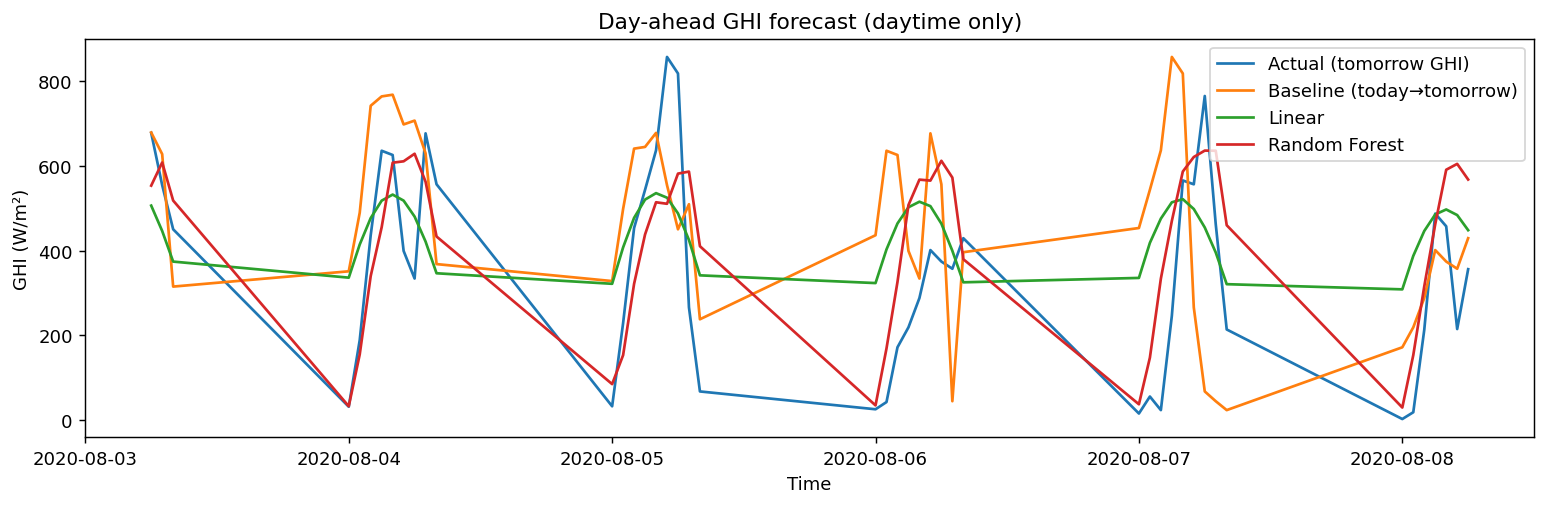

In [21]:
test_index = y_test.index
cs_test = df_da.loc[test_index, 'Clearsky GHI']

day_mask = cs_test > 300  # high-irradiance hours only

# Plot 5 days of daytime points
n_days = 5
mask_5d = day_mask.copy()
mask_5d.loc[mask_5d.index > mask_5d.index.min() + pd.Timedelta(days=n_days)] = False

idx = test_index[mask_5d]

plt.figure(figsize=(12,4))
plt.plot(idx, y_test.loc[idx], label="Actual (tomorrow GHI)")
plt.plot(idx, y_pred_base[mask_5d.values], label="Baseline (today→tomorrow)")
plt.plot(idx, y_pred_lin[mask_5d.values], label="Linear")
plt.plot(idx, y_pred_rf[mask_5d.values], label="Random Forest")
plt.title("Day-ahead GHI forecast (daytime only)")
plt.xlabel("Time")
plt.ylabel("GHI (W/m²)")
plt.legend()
plt.tight_layout()
plt.show()


## Report skill vs Baseline

In [22]:
def skill(rmse_model, rmse_base):
    return 100.0 * (rmse_base - rmse_model) / rmse_base

print("Skill (Linear):", skill(rmse_lin, rmse_base), "%")
print("Skill (RF):", skill(rmse_rf, rmse_base), "%")


Skill (Linear): 19.686408012678385 %
Skill (RF): 34.736044502250934 %


## Results: Day-Ahead Solar Forecasting

A persistence baseline assuming tomorrow’s irradiance equals today’s conditions at the same hour yielded an RMSE of **271.5 W/m²**, highlighting the limited predictive skill of naive day-ahead persistence under tropical cloud variability.

A linear regression model incorporating calendar information, clear-sky irradiance, and lagged persistence reduced the RMSE to **218.1 W/m²**, corresponding to a **~20% improvement** over the baseline.

The Random Forest model achieved the best performance, with a day-ahead RMSE of **177.2 W/m²**, representing a **~35% reduction in error** relative to the persistence baseline. This improvement reflects the model’s ability to capture nonlinear relationships between solar geometry, recent irradiance history, and meteorological variability, while remaining constrained by the intrinsic unpredictability of cloud processes at the day-ahead horizon.


# Feature Importance (Day-Ahead RF)

In [23]:

feature_importance = pd.Series(
    rf.feature_importances_,
    index=FEATURE_COLS_DA
).sort_values(ascending=False)

feature_importance


Clearsky GHI         0.327763
dayofyear            0.221749
hour                 0.157274
Temperature          0.084848
Relative Humidity    0.045382
Wind Direction       0.045190
GHI_lag24            0.043141
GHI_roll24           0.040470
Wind Speed           0.027975
month                0.006209
dtype: float64

## Plot and save Feature Importance

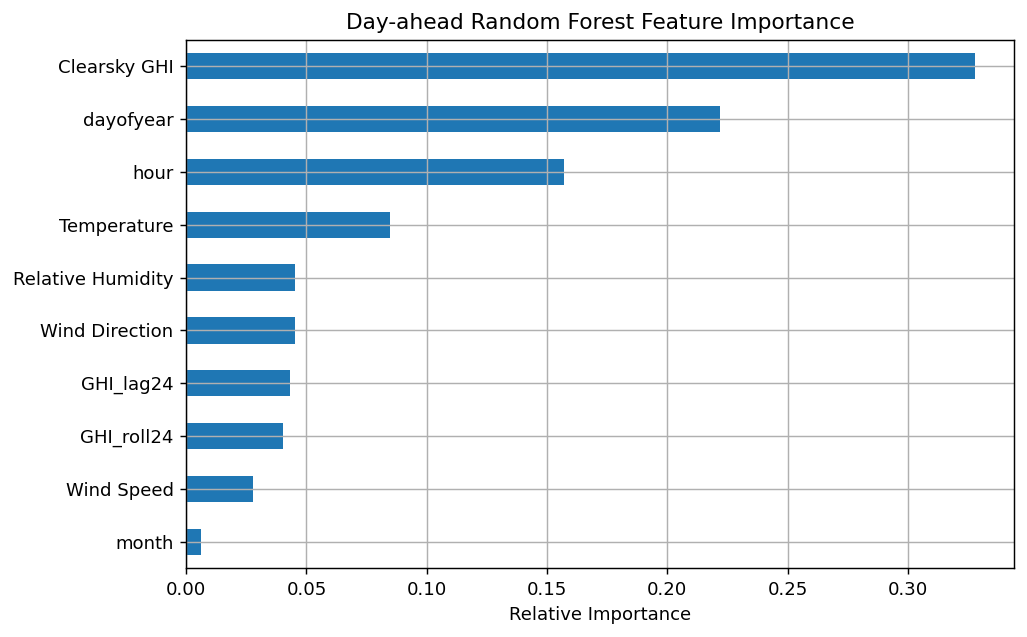

In [24]:
plt.figure(figsize=(8,5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Day-ahead Random Forest Feature Importance")
plt.xlabel("Relative Importance")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/rf_feature_importance_day_ahead.png", dpi=150)
plt.show()


## Feature Importance Discussion

Feature importance analysis indicates that clear-sky irradiance and diurnal/seasonal timing dominate day-ahead solar predictability, while meteorological variables provide secondary nonlinear corrections. This reflects the strong role of solar geometry in setting the upper bound on forecast skill.


# Convert GHI to PV Power

## Define a simple PV conversion model

In [25]:
# PV system assumptions
PV_EFFICIENCY = 0.18     # 18% typical crystalline silicon
PV_AREA = 10.0           # m² (small rooftop system)

def ghi_to_pv_power(ghi):
    """
    Convert GHI (W/m²) to PV power output (W)
    """
    return ghi * PV_AREA * PV_EFFICIENCY


## Compute Actual vs Predicted PV Power

In [26]:
pv_actual = ghi_to_pv_power(y_test)
pv_pred_rf = ghi_to_pv_power(y_pred_rf)
pv_pred_base = ghi_to_pv_power(y_pred_base)

### Plot PV Power (Daytime only)

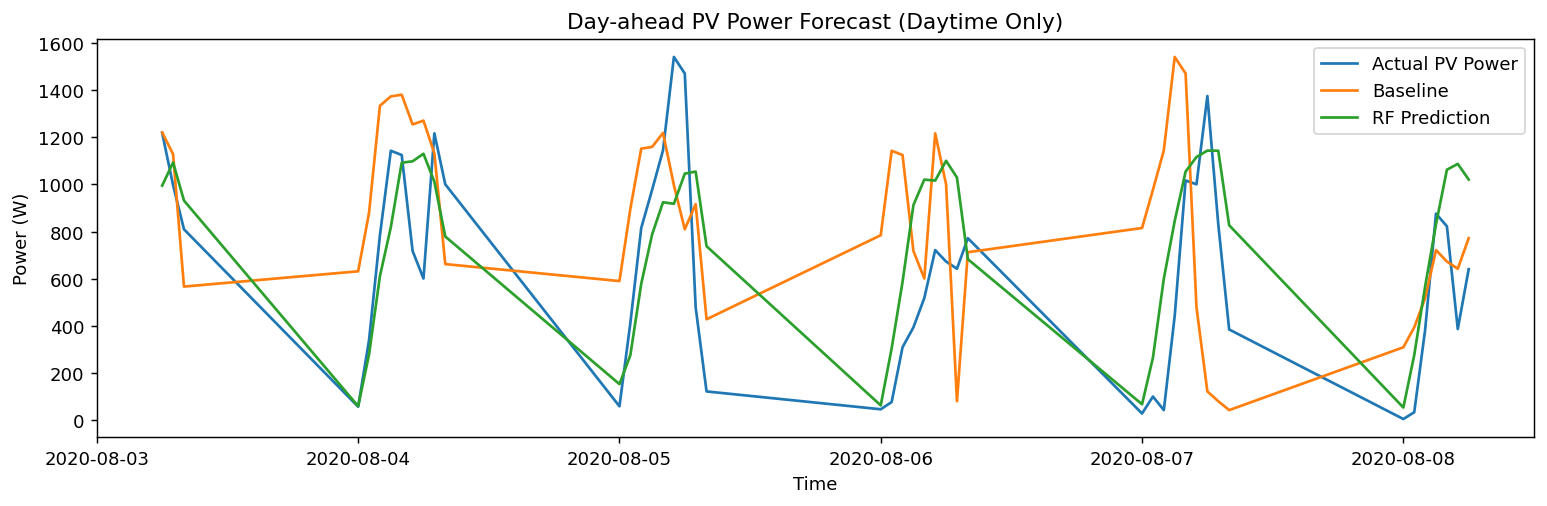

In [27]:
# Daytime-only for plotting
cs_test = df_da.loc[y_test.index, 'Clearsky GHI']
day_mask = cs_test > 300

# Plot first 5 days
n_days = 5
mask_5d = day_mask.copy()
mask_5d.loc[mask_5d.index > mask_5d.index.min() + pd.Timedelta(days=n_days)] = False
idx = y_test.index[mask_5d]

plt.figure(figsize=(12,4))
plt.plot(idx, pv_actual.loc[idx], label="Actual PV Power")
plt.plot(idx, pv_pred_base[mask_5d.values], label="Baseline")
plt.plot(idx, pv_pred_rf[mask_5d.values], label="RF Prediction")
plt.title("Day-ahead PV Power Forecast (Daytime Only)")
plt.ylabel("Power (W)")
plt.xlabel("Time")
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/pv_power_day_ahead.png", dpi=150)
plt.show()


### Daily Energy Error

In the energy sector, they care mor eabout **daily kWh** rather than just hourly **W**

In [28]:
# Convert to daily energy (Wh → kWh)
pv_df = pd.DataFrame({
    "actual": pv_actual,
    "pred_rf": pv_pred_rf
}, index=y_test.index)

daily_energy = pv_df.resample("D").sum() / 1000  # kWh

daily_energy.head()


,actual,pred_rf
datetime,,
2020-08-03,4.7682,4.342952
2020-08-04,8.1234,8.222467
2020-08-05,7.2558,7.862555
2020-08-06,4.9986,8.011309
2020-08-07,5.8410,8.413970


### Plot Daily PV Energy Error

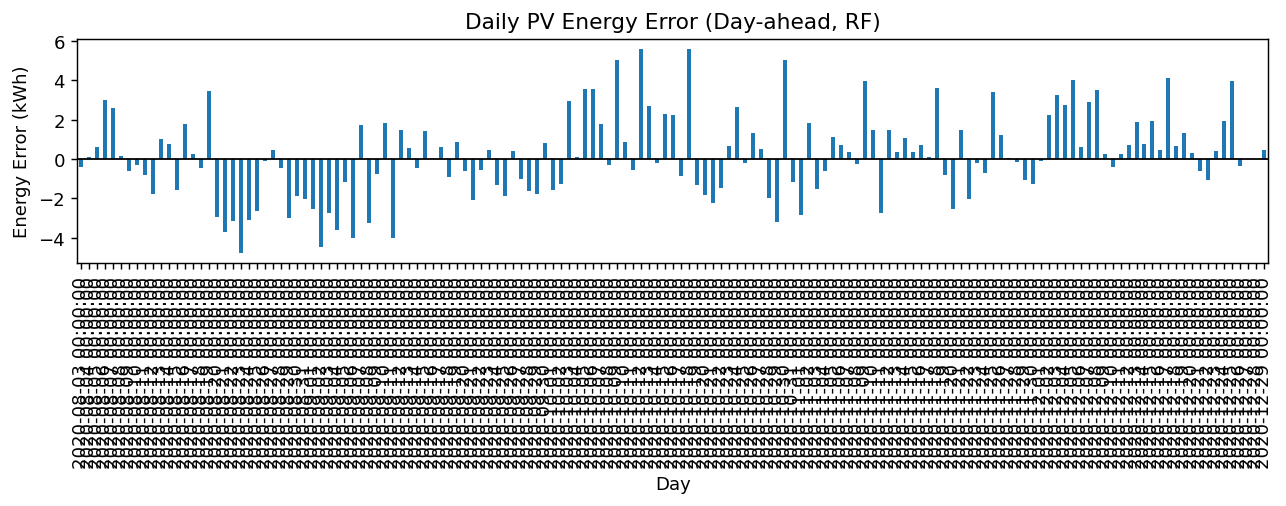

In [29]:
energy_error = daily_energy["pred_rf"] - daily_energy["actual"]

plt.figure(figsize=(10,4))
energy_error.plot(kind="bar")
plt.axhline(0, color="black", linewidth=1)
plt.title("Daily PV Energy Error (Day-ahead, RF)")
plt.ylabel("Energy Error (kWh)")
plt.xlabel("Day")
plt.tight_layout()
plt.savefig(f"figures/pv_daily_energy_error.png", dpi=150)
plt.show()


## PV Conversion

To translate irradiance forecasts into an energy-relevant metric, GHI was converted to photovoltaic power using a simplified fixed-efficiency PV model. While idealized, this approach provides an interpretable estimate of forecast impact on power production and daily energy yield.
